# **EDA & Preprocessing**

In [5]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
# Load the Dataset

dataset = pd.read_csv('online_shoppers_intention.csv')
dataset.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [7]:
# Checking the data types

dataset.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [8]:
# Checking the dataset shape

dataset.shape

(12330, 18)

In [9]:
# Re-validating the dataset for missing values

dataset.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [10]:
# Checking is there any duplicated rows in the dataset

dataset.duplicated().sum()

np.int64(125)

In [11]:
# Checking the distribution of the target variable, the target of this dataset is 'Revenue'

dataset['Revenue'].value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

In [12]:
# Due to duplpicated values in the dataset, we will drop the duplicated rows

dataset.drop_duplicates(inplace=True)

In [13]:
# New dataset shape after dropping duplicated rows

dataset.shape

(12205, 18)

# **EDA**

**Univariate**

In [ ]:
# Numerical Features 

num_cols = ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration',
             'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

In [ ]:
# Checking the skewness of the numerical features

dataset[num_cols].skew().sort_values(ascending=False)

Informational_Duration     7.540291
ProductRelated_Duration    7.253161
PageValues                 6.350983
Administrative_Duration    5.592152
ProductRelated             4.333419
Informational              4.014173
SpecialDay                 3.285902
BounceRates                3.162425
ExitRates                  2.234645
Administrative             1.947123
dtype: float64

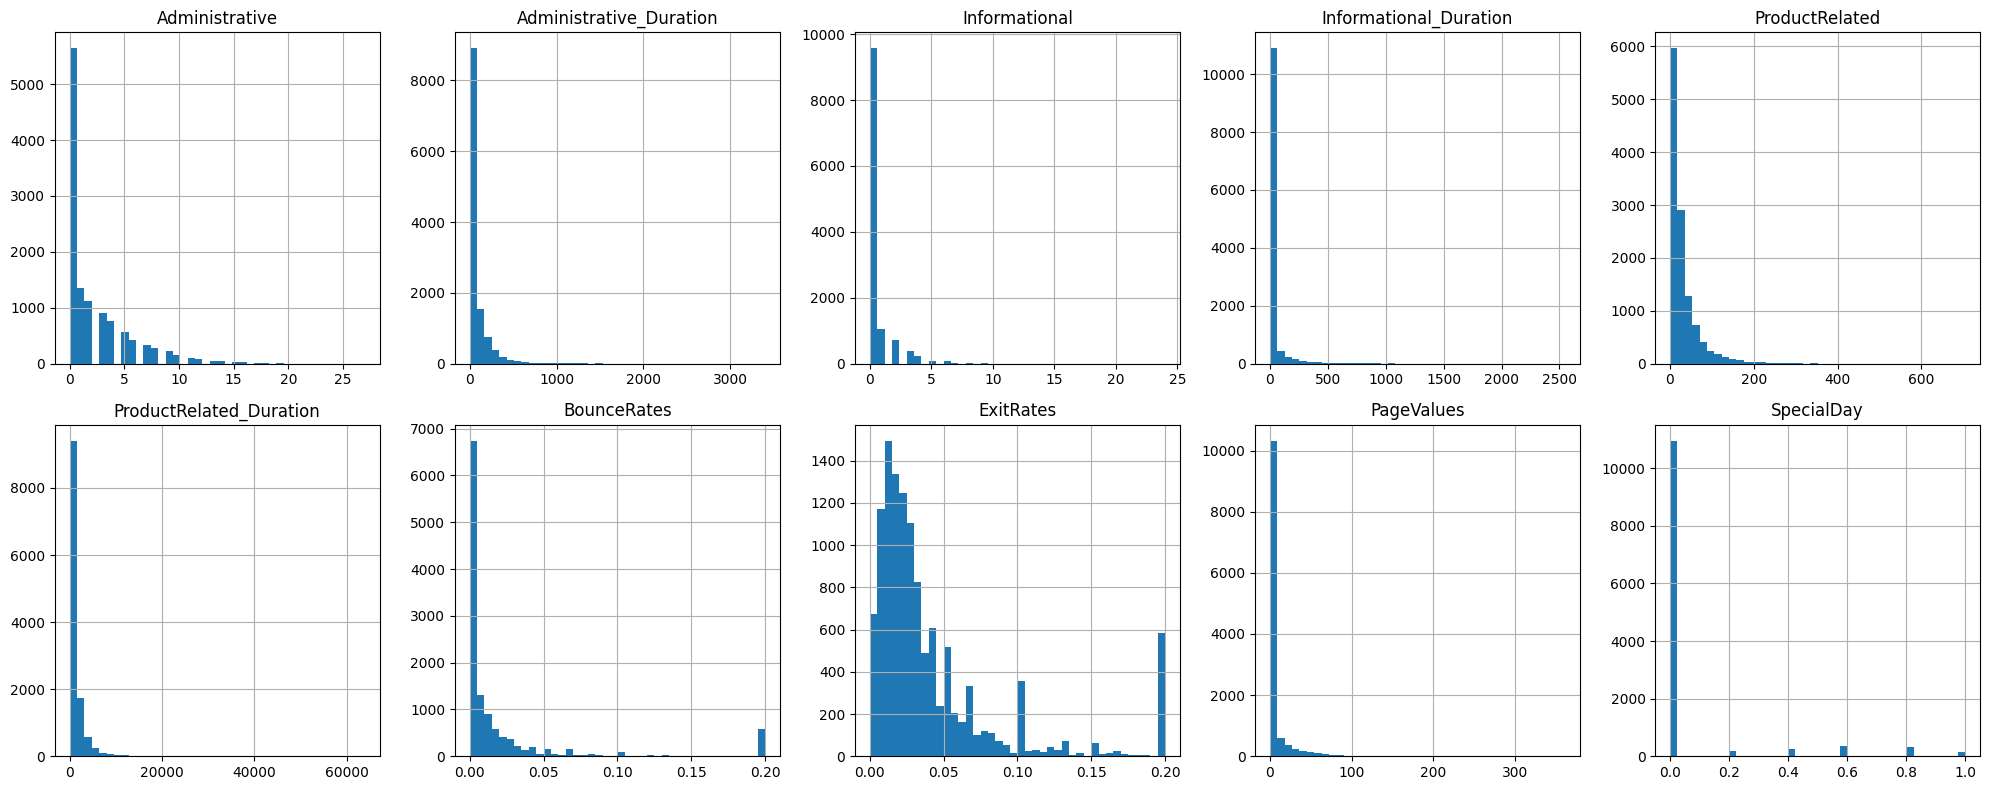

In [ ]:
# Visualization  spot putliers and skewness of the numerical features

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, col in enumerate(num_cols):
    dataset[col].hist(ax=axes[i//5, i%5], bins=40)
    axes[i//5, i%5].set_title(col)
plt.tight_layout()
plt.show()

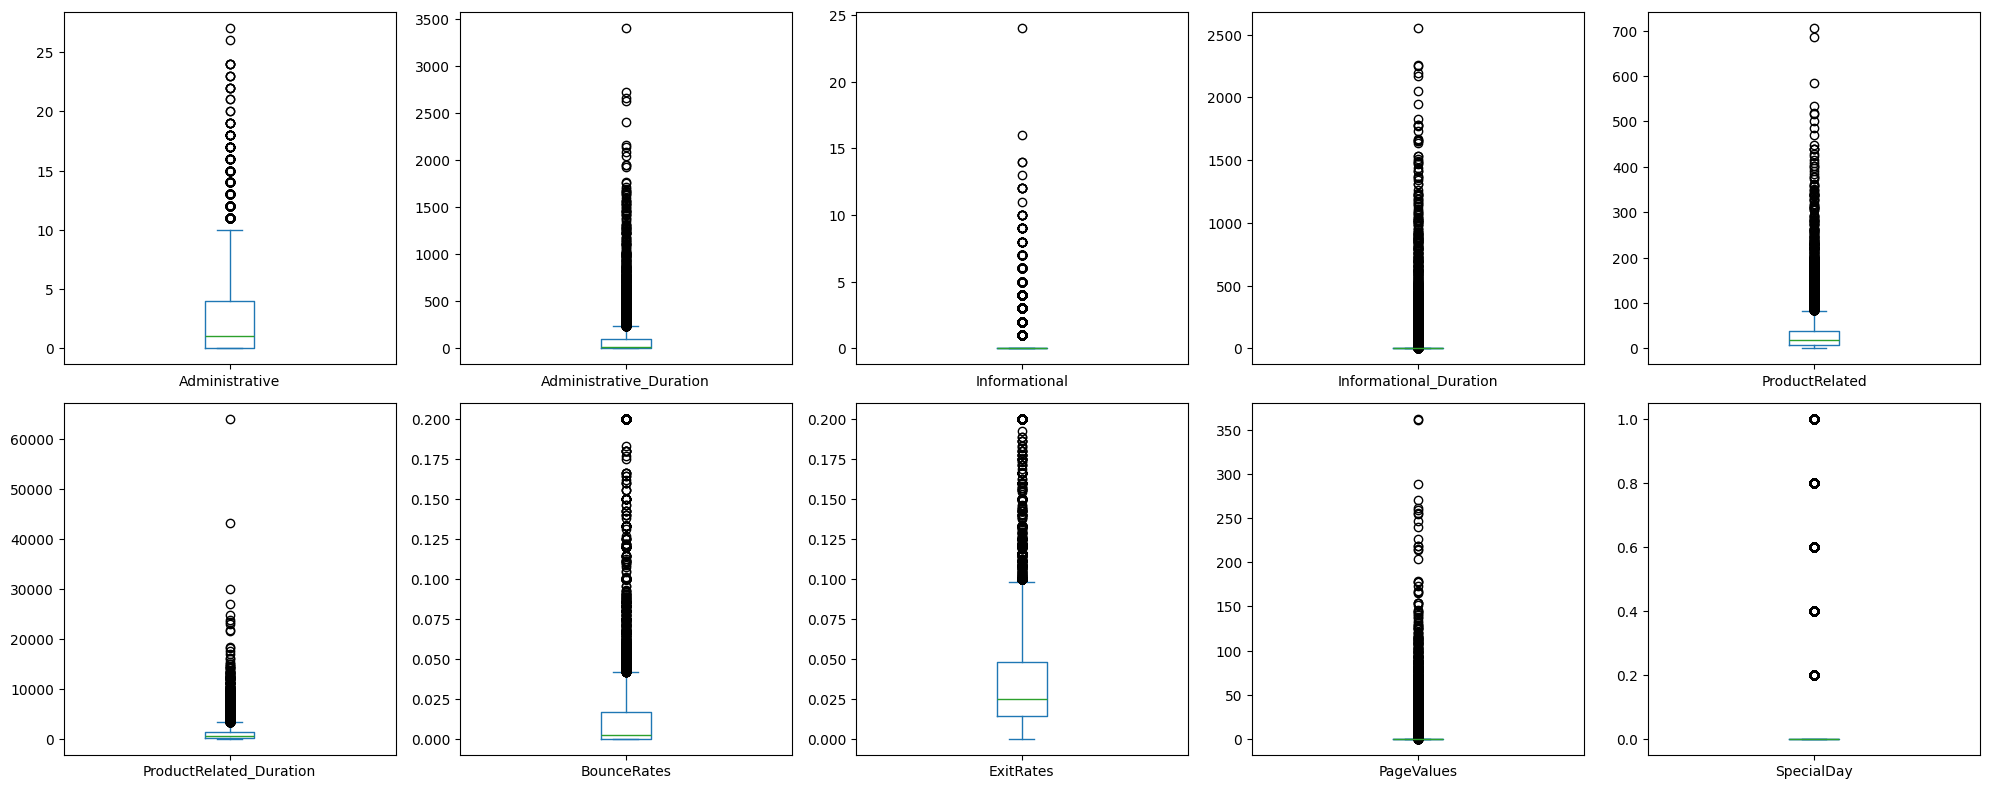

In [17]:
# Boxplots for outliers visibility

dataset[num_cols].plot(kind='box', subplots=True, layout=(2, 5), figsize=(20, 8), sharey=False)
plt.tight_layout()
plt.show()

In [18]:
# Categorical Features

cat_cols = ['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType']

In [19]:
for col in cat_cols:
    print(dataset[col].value_counts(), '\n')

Month
May     3329
Nov     2982
Mar     1860
Dec     1706
Oct      549
Sep      448
Aug      433
Jul      432
June     285
Feb      181
Name: count, dtype: int64 

OperatingSystems
2    6541
1    2549
3    2530
4     478
8      75
6      19
7       7
5       6
Name: count, dtype: int64 

Browser
2     7883
1     2427
4      731
5      465
6      174
10     163
8      135
3      105
13      56
7       49
12      10
11       6
9        1
Name: count, dtype: int64 

Region
1    4714
3    2379
4    1171
2    1128
6     801
7     758
9     505
8     431
5     318
Name: count, dtype: int64 

TrafficType
2     3911
1     2388
3     2013
4     1066
13     728
10     450
6      443
8      343
5      260
11     247
20     193
9       41
7       40
15      37
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64 

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64 

